# Bathymetry along transects A–E
NOAA NCEI 1/9 arc-sec CUDEM topobathy (Hawaii, tile n21x50_w158x25, vertical datum MSL) sampled along the transect lines in `ewa_Sensor_new.kml` (A, C, D, E) and a constructed line for B. x = 0 at the shoreline (offshore → negative, onshore → positive).

In [1]:
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt
from PIL import Image
from pyproj import Transformer
from scipy.ndimage import map_coordinates

# ---------------- INPUTS ----------------
KML      = '../ewa_Sensor_new.kml'
NOTES    = '../data/metadata/sensor_notes.csv'
DEM      = '../data/external/bathy/ncei19_n21x50_w158x25_2021v1.tif'
FIG_DIR  = '../figs/initial'
TRANSECTS = ['A','B','C','D','E']
KML_ID   = {'A':'6625','C':'6615','D':'6605','E':'6595'}   # SimpleData id of each transect line in the KML
B_SENSOR, B_BEARING = 'VB5', 336.0      # B has no KML line: run through VB5 along its shore-normal
B_OFFSHORE_M, B_ONSHORE_M = 6500., 3500.
DS       = 5.0                          # sample spacing along line (m)
XLIM     = (-1500, 0)                # plotted distance from shore (m)
YLIM     = (-20, 0)
T_COLOR  = {'A':'indianred','B':'indianred','C':'#708238','D':'#0047AB','E':'0.15'}
T_LS     = {'A':'-','B':'--','C':'-','D':'-','E':'-'}
plt.rcParams.update({'axes.spines.top':False,'axes.spines.right':False,'axes.linewidth':0.8,
  'axes.titlesize':15,'xtick.labelsize':12,'ytick.labelsize':12,'axes.labelsize':13,'lines.linewidth':1.6})


In [2]:
# DEM (GeoTIFF, EPSG:4326, pixel-is-area, upper-left corner from ModelTiepoint)
Image.MAX_IMAGE_PIXELS = None
im   = Image.open(DEM)
dx, dy = im.tag_v2[33550][:2]
lon0, lat0 = im.tag_v2[33922][3:5]
dem  = np.array(im, dtype='float32'); del im
def_nodata = dem < -9000
dem[def_nodata] = np.nan
print(dem.shape, 'lon0 %.5f lat0 %.5f res %.2e deg'%(lon0,lat0,dx))

# transect endpoints (offshore end -> onshore end), lon/lat
kml = open(KML).read()
ends = {}
for pm in re.findall(r'<Placemark.*?</Placemark>', kml, re.S):
    for T,i in KML_ID.items():
        if '>%s<'%i in pm and '<LineString' in pm:
            co = re.search(r'<coordinates>(.*?)</coordinates>', pm, re.S).group(1).split()
            co = np.array([[float(v) for v in p.split(',')] for p in co])
            ends[T] = (co[0,:2], co[-1,:2])
notes = pd.read_csv(NOTES)
print(notes.columns.tolist())


(8112, 8112) lon0 -158.25019 lat0 21.50019 res 3.09e-05 deg
['Sensor Assignment', 'Deployment Site Name', 'Processed Data Sensor Name (.nc file)', 'S/N ', 'Deployment Latitude (WGS84)', 'Deployment Longitude (WGS84)', 'UTM Northings (Zone 4)', 'UTM Eastings (Zone 4)', 'Deployment Depth MSL(m), approximate ', 'Orientation', 'Magnetic Heading (KVH)', 'Heading Notes', 'Transect', 'Shoreline Heading W to E (deg true)', 'Shore Normal Onshore (deg true)', 'Position Notes', 'Installation Method', 'Deployment Duration', 'Sample Rate', 'Clock Drift (seconds) over Deployment Duration***', 'PC used for download', 'Original Download Location', 'Backed up to reefbreak?', 'Backed up to HNL Google Drive?', 'notes', 'data processing notes']


In [3]:
to_xy = Transformer.from_crs(4326, 32604, always_xy=True)
nm, la, lo, dp = (notes.columns[2], notes.columns[4], notes.columns[5], notes.columns[8])
sens = notes.set_index(nm)

# B line: through VB5 along its shore-normal onshore bearing (no KML line for B)
x0, y0 = to_xy.transform(sens.loc[B_SENSOR, lo], sens.loc[B_SENSOR, la])
ux, uy = np.sin(np.radians(B_BEARING)), np.cos(np.radians(B_BEARING))
xyB = [(x0-B_OFFSHORE_M*ux, y0-B_OFFSHORE_M*uy), (x0+B_ONSHORE_M*ux, y0+B_ONSHORE_M*uy)]

prof = {}
for T in TRANSECTS:
    if T == 'B': p0, p1 = [np.array(p) for p in xyB]
    else:        p0, p1 = [np.array(to_xy.transform(*e)) for e in ends[T]]
    L = np.hypot(*(p1-p0)); s = np.arange(0, L+DS, DS)
    xy = p0 + np.outer(s/L, p1-p0)
    lon, lat = to_xy.transform(xy[:,0], xy[:,1], direction='INVERSE')
    col = (np.asarray(lon)-lon0)/dx - 0.5       # pixel centres
    row = (lat0-np.asarray(lat))/dx - 0.5
    z = map_coordinates(dem, [row, col], order=1, mode='nearest')
    # shoreline: last upward crossing of 0 m seaward of which the profile stays >= 0 for the next 100 m
    up = np.where((z[:-1] < 0) & (z[1:] >= 0))[0]
    k = [i for i in up if (z[i+1:i+1+int(100/DS)] >= 0).all()]
    ish = k[0] if k else up[-1]
    sshore = s[ish] + DS*(0-z[ish])/(z[ish+1]-z[ish])
    prof[T] = dict(s=s, x=s-sshore, z=z, p0=p0, p1=p1, L=L, ux=(p1-p0)/L)
    print(T, 'length %.0f m, shoreline at %.0f m from offshore end, %d upward crossings'%(L, sshore, len(up)))


A length 4209 m, shoreline at 2764 m from offshore end, 1 upward crossings
B length 10000 m, shoreline at 7377 m from offshore end, 1 upward crossings
C length 4070 m, shoreline at 2716 m from offshore end, 1 upward crossings
D length 3856 m, shoreline at 2505 m from offshore end, 1 upward crossings
E length 3778 m, shoreline at 2266 m from offshore end, 1 upward crossings


In [4]:
# sensors projected onto each transect (cross-shore position and DEM depth there)
for T in TRANSECTS:
    P = prof[T]; P['sens'] = []
    for S in sens.index:
        if not (isinstance(S,str) and S[0] in 'VP' and S[1]==T): continue
        x, y = to_xy.transform(sens.loc[S, lo], sens.loc[S, la])
        sp = np.dot(np.array([x,y])-P['p0'], P['ux'])
        off = np.hypot(*(np.array([x,y])-P['p0']-sp*P['ux']))
        xs = sp - (P['s'] - P['x'])[0]
        zd = np.interp(xs, P['x'], P['z'])
        dnom = float(re.match(r'\s*-?[\d.]+', str(sens.loc[S, dp])).group()) if re.match(r'\s*-?[\d.]+', str(sens.loc[S, dp])) else np.nan
        P['sens'].append((S, xs, dnom, zd, off))
        print('%s: x=%7.0f m  nominal %.1f m  DEM %6.1f m  (%.0f m off line)'%(S, xs, dnom, zd, off))


VA10: x=   -999 m  nominal -10.0 m  DEM  -10.1 m  (71 m off line)
VB5: x=   -877 m  nominal -5.5 m  DEM   -5.1 m  (0 m off line)
PB1: x=   -109 m  nominal nan m  DEM   -1.4 m  (288 m off line)
PB2: x=   -225 m  nominal nan m  DEM   -1.7 m  (280 m off line)
VC5: x=   -707 m  nominal -5.0 m  DEM   -5.0 m  (2 m off line)
VC10: x=  -1360 m  nominal -10.0 m  DEM  -10.0 m  (1 m off line)
PC1: x=   -174 m  nominal nan m  DEM   -2.0 m  (3 m off line)
VD10: x=  -1183 m  nominal -10.0 m  DEM  -10.3 m  (15 m off line)
VD5: x=   -768 m  nominal -5.0 m  DEM   -5.0 m  (11 m off line)
PD1: x=   -221 m  nominal nan m  DEM   -2.4 m  (13 m off line)
VE7: x=   -921 m  nominal -7.0 m  DEM   -7.0 m  (3 m off line)
VE10: x=  -1319 m  nominal -10.0 m  DEM  -10.1 m  (26 m off line)
VE4: x=   -514 m  nominal -4.0 m  DEM   -4.0 m  (2 m off line)
PE1: x=   -221 m  nominal nan m  DEM   -2.4 m  (17 m off line)


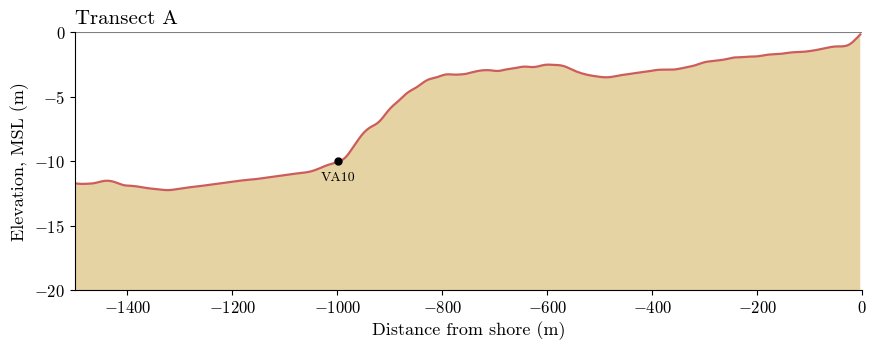

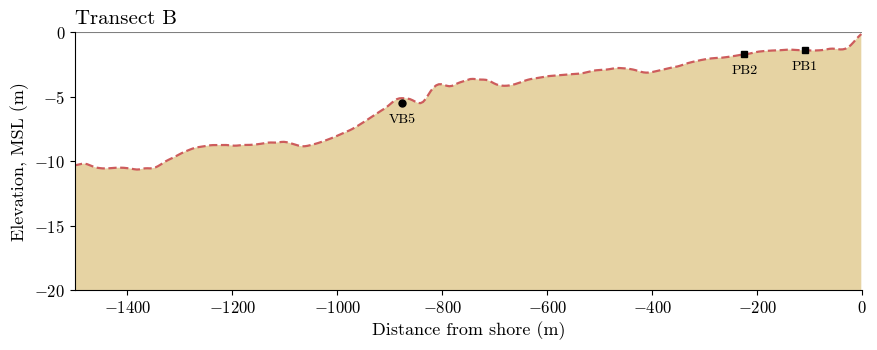

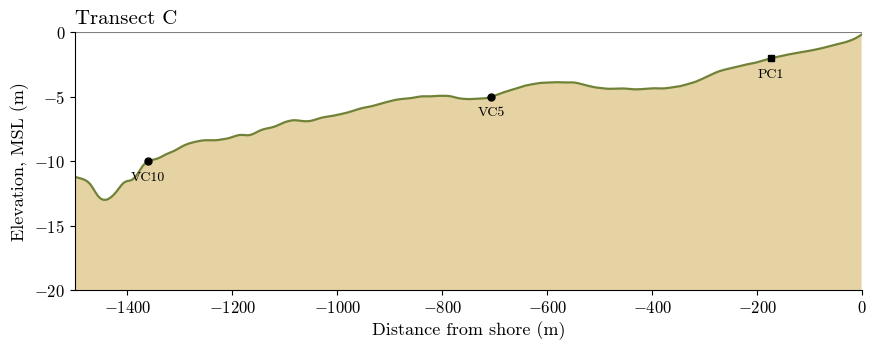

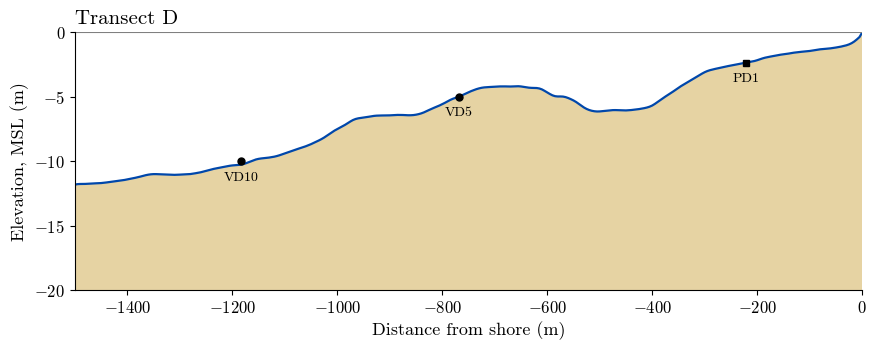

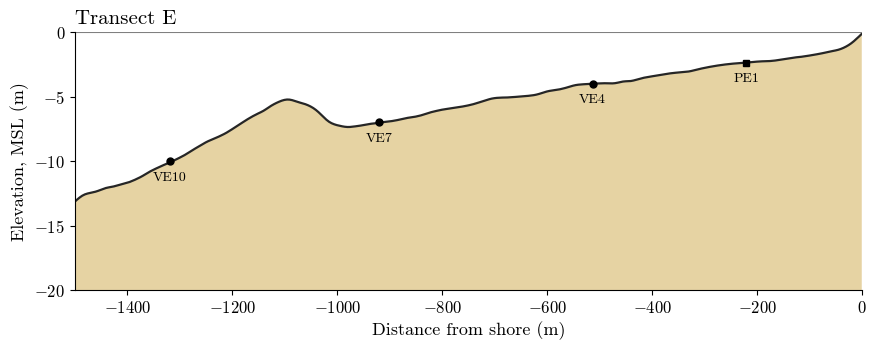

In [5]:
SAND = '#E6D3A3'
for T in TRANSECTS:
    P = prof[T]; m = P['x'] <= 0                      # seaward of the shoreline only
    fig, ax = plt.subplots(figsize=(9, 3.6))
    ax.fill_between(P['x'][m], P['z'][m], YLIM[0], color=SAND, lw=0)
    ax.plot(P['x'][m], P['z'][m], color=T_COLOR[T], ls=T_LS[T])
    ax.axhline(0, color='0.5', lw=0.8)
    for S, xs, d, zd, off in P['sens']:
        # Vectors at nominal depth; Paros have no nominal depth, so placed on the DEM at their cross-shore position
        if S[0]=='V': ax.plot(xs, d, 'o', color='k', ms=5); ax.annotate(S, (xs, d), textcoords='offset points', xytext=(0,-14), ha='center', fontsize=10)
        else:         ax.plot(xs, zd, 's', color='k', ms=5); ax.annotate(S, (xs, zd), textcoords='offset points', xytext=(0,-14), ha='center', fontsize=10)
    ax.set_title('Transect %s'%T, loc='left'); ax.set_ylabel('Elevation, MSL (m)')
    ax.set_xlabel('Distance from shore (m)')
    ax.set_xlim(*XLIM); ax.set_ylim(*YLIM)
    fig.tight_layout()
    fig.savefig(FIG_DIR+'/bathy_%s.png'%T, dpi=200)
    plt.show()
